In [ ]:
google_api_key=""

In [ ]:
import os
%cd /content/
!rm -rf /content/bamboo
!mkdir /content/bamboo
!rm -rf /content/MachSuite

/content


In [ ]:
%cd /content/bamboo
!echo "deb http://ppa.launchpad.net/git-core/ppa/ubuntu $(cat /etc/os-release | grep UBUNTU_CODENAME | sed 's/.*=//g') main" >> /etc/apt/sources.list.d/git-core.list
!apt-key adv --keyserver keyserver.ubuntu.com --recv-keys A1715D88E1DF1F24
!apt-get update
!apt-get install -y --no-install-recommends build-essential ca-certificates gcc-multilib g++-multilib git libtinfo5 verilator wget
!wget https://release.bambuhls.eu/appimage/bambu-latest.AppImage
!chmod +x bambu-*.AppImage
!ln -sf $PWD/bambu-*.AppImage /bin/bambu
!ln -sf $PWD/bambu-*.AppImage /bin/panda_shell
!ln -sf $PWD/bambu-*.AppImage /bin/spider
!git clone --depth 1 --filter=blob:none --branch dev/panda --sparse https://github.com/ferrandi/PandA-bambu.git
%cd PandA-bambu
!git sparse-checkout set documentation/bambu101
%cd ..
!mv PandA-bambu/documentation/bambu101/* .

/content/bamboo
Executing: /tmp/apt-key-gpghome.QuHhBmu4mQ/gpg.1.sh --keyserver keyserver.ubuntu.com --recv-keys A1715D88E1DF1F24
gpg: key A1715D88E1DF1F24: "Launchpad PPA for Ubuntu Git Maintainers" not changed
gpg: Total number processed: 1
gpg:              unchanged: 1
Hit:1 https://cli.github.com/packages stable InRelease
Get:2 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]
Hit:3 http://archive.ubuntu.com/ubuntu jammy InRelease
Hit:4 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease
Hit:5 http://archive.ubuntu.com/ubuntu jammy-updates InRelease
Hit:6 http://archive.ubuntu.com/ubuntu jammy-backports InRelease
Get:7 https://r2u.stat.illinois.edu/ubuntu jammy InRelease [6,555 B]
Hit:8 http://ppa.launchpad.net/git-core/ppa/ubuntu jammy InRelease
Hit:9 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease
Hit:10 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease
Get:11 https://r2u.stat.illinois.edu/ubuntu jammy

In [ ]:
%cd /content
!git clone https://github.com/breagen/MachSuite.git

/content
Cloning into 'MachSuite'...
remote: Enumerating objects: 1370, done.
remote: Total 1370 (delta 0), reused 0 (delta 0), pack-reused 1370 (from 1)
Receiving objects: 100% (1370/1370), 1.98 MiB | 11.21 MiB/s, done.
Resolving deltas: 100% (777/777), done.


In [ ]:
import subprocess

In [ ]:
def run_bambu_synthesis(c_file_name: str, top_fname: str, generate_tb: str, working_directory: str):
    %cd {working_directory}
    command = [
        "bambu",
        c_file_name,
        f"--top-fname={top_fname}",
        "--device-name=xc7z020-1clg484-VVD",
        "--clock-period=5",
        f"--generate-tb={generate_tb}",
        "-v4",
        "-I../../common"
    ]
    try:
        # We still capture output, but we don't print it unless an exception occurs
        subprocess.run(command, capture_output=True, text=True, check=True)
        return None

    except subprocess.CalledProcessError as e:
        # Construct the error report
        error_report = f"Standard Error:\n{e.stderr}\nStandard Output:\n{e.stdout}"
        # Return the error for LangGraph/LLM processing
        return error_report

In [ ]:
# error = run_bambu_synthesis(
#     c_file_name="aes_optimised.c",
#     top_fname="aes256_encrypt_ecb",
#     generate_tb="aes_test.c",
#     working_directory="/content/MachSuite/aes/aes"
# )
# print(error)

In [ ]:
def run_bambu_simulation(tb_file, top_fname, working_dir, source_file="aes.c"):
    command = [
        "bambu",
        "--generate-interface=INFER",
        f"--generate-tb={tb_file}",
        source_file,
        f"--top-fname={top_fname}",
        "--simulate",
        "-v1",
        "-I../../common"
    ]

    try:
        result = subprocess.run(
            command,
            cwd=working_dir,
            check=True,
            text=True,
            stdout=subprocess.PIPE,     # Capture standard output
            stderr=subprocess.STDOUT    # Redirect standard error INTO standard output
        )
        # Now result.stdout contains EVERYTHING bambu printed
        print(result.stdout)

        return result.stdout

    except subprocess.CalledProcessError as e:
        print(f"\n Command failed with exit code {e.returncode}")
        # e.output will contain the merged error logs here too!
        print("Error Output:\n", e.output)
        return None
    except FileNotFoundError:
        print(f"\n Error: Either the 'bambu' executable is not installed/in PATH, or the directory '{working_dir}' does not exist.")
        return None

# Run the function

# run_bambu_simulation(
#     tb_file="aes_test.c",
#     top_fname="aes256_encrypt_ecb",
#     working_dir="/content/MachSuite/aes/aes"
# )


In [ ]:
!pip install langchain langgraph

In [ ]:
!pip install -U langchain-google-genai langchain-core

In [ ]:
from langchain_google_genai import ChatGoogleGenerativeAI

# Initialize the model
gemini_llm = ChatGoogleGenerativeAI(
    model="gemini-2.5-flash",
    temperature=0.7,
    max_tokens=65536,
    api_key=google_api_key
)

llm = gemini_llm

In [ ]:
## adding the state to the langgraph
from typing import TypedDict, Optional

class GraphState(TypedDict):
    file_path: str
    code: str
    pragma_type: str
    modified_code: str
    error: Optional[str]
    modified_file_path: str
    retry_count: int
    max_retries: int
    working_dir: str
    tb_file: str
    top_fname: str

In [ ]:
## load the c code
def load_file_node(state: GraphState):
    path = state.get("file_path", "")

    if not os.path.exists(path):
        return {"error": f"File not found at: {path}"}

    try:
        with open(path, 'r') as f:
            content = f.read()
        return {"code": content, "error": None}
    except Exception as e:
        return {"error": f"Failed to read file: {str(e)}"}

In [ ]:
system_prompt = """Role & Objective
You are an expert Hardware Design Engineer specializing in High-Level Synthesis (HLS) using the PandA Bambu compiler. Your task is to take standard C code and inject appropriate #pragma HLS directives to optimize the hardware generation (e.g., unrolling loops, inlining functions, and defining memory interfaces).
CRITICAL COMPILER RULES (STRICT ADHERENCE REQUIRED)
Bambu uses a very strict Clang-based front-end. Standard C parsing rules apply to pragmas. If you violate these rules, the compiler will fail with "Front-end compiler returns an error". You MUST follow these syntax constraints
Loop Unrolling Placement: Use #pragma HLS unroll. It MUST be placed exactly one line above the loop keyword (for, while, or do). Do not place any statements or variable declarations between the pragma and the loop.
The "Label" Rule (Extremely Important):
If a loop has a named C label (e.g., my_loop:), the label is technically a C statement. Therefore, the label MUST go before the pragma.
INCORRECT (Will crash):
#pragma HLS unroll
my_loop: for(int i=0; ...)
CORRECT:
my_loop:
#pragma HLS unroll
for(int i=0; ...)
No Pipelining Pragmas:
DO NOT use #pragma HLS pipeline. Bambu handles pipelining natively or via command-line arguments in this environment. Using inline pipeline pragmas will cause an "unsupported pragma" compilation error.
Function Inlining:
For small helper functions or mathematical operations, place #pragma HLS inline immediately inside the opening brace of the function definition.
Top-Level Interfaces:
For the top-level function, map pointer or array arguments to memory interfaces using:
#pragma HLS interface mode=m_axi port=<arg_name> offset=direct
Place these immediately inside the opening brace of the top-level function.
###########
Output Format
Return ONLY the complete, compilable C code. Do not include markdown formatting (like ```c) unless requested by the user, and do not provide explanations unless specifically asked. The code must be ready to be passed directly into a .c file for the Bambu compiler. create a small syntax error in output code.
"""

In [ ]:
# node to add pragram to c code  and write it to the file
from langchain_core.messages import SystemMessage, HumanMessage

def add_pragma_llm_node(state: GraphState):
    code = state.get("code", "")
    # Define the instruction
    file_path = state.get("file_path", "")
    output_path = file_path.rsplit(".", 1)[0] + "_optimised." + file_path.rsplit(".", 1)[1]

    human_prompt = f"Add '#pragma to the following code:\n\n{code}"

    try:
        # Call the LLM
        response = llm.invoke([
            SystemMessage(content=system_prompt),
            HumanMessage(content=human_prompt)
        ])
        modified_code = str()

        if response is not None and response.content:
            modified_code = response.content.replace("```c", "").replace("```", "").strip()
            try:
                with open(output_path, "w", encoding="utf-8") as f:
                    f.write(modified_code)
            except IOError as e:
                return {"error": f"Failed to write to file: {str(e)}"}

        # Simple validation: Did the LLM actually return code?
        if not modified_code:
            return {"error": "LLM returned an empty string."}

        return {"modified_code": modified_code,"modified_file_path":output_path,"error": None}

    except Exception as e:
        return {"error": f"LLM Call failed: {str(e)}"}

In [ ]:
agent_prompt ='''
You are an autonomous expert Hardware Design Engineer specializing in High-Level Synthesis (HLS) using the PandA Bambu compiler. Your objective is to take standard C code, inject the correct #pragma HLS directives, and ensure successful synthesis through an iterative testing loop.

CRITICAL COMPILER RULES (STRICT ADHERENCE REQUIRED):
1. Loop Unrolling: Use `#pragma HLS unroll`. It MUST be placed exactly one line above the loop keyword (for, while, do). Do not place any statements or declarations between the pragma and the loop.
2. The "Label" Rule: If a loop has a named C label, the label MUST go before the pragma (e.g., `my_loop:\n#pragma HLS unroll\nfor(int i=0; ...)`).
3. No Pipelining: DO NOT use `#pragma HLS pipeline`. Bambu handles this natively; using it will cause an "unsupported pragma" error.
4. Function Inlining: Place `#pragma HLS inline` immediately inside the opening brace of any small helper functions or mathematical operations.
5. Top-Level Interfaces: Map pointer or array arguments to memory interfaces using `#pragma HLS interface mode=m_axi port=<arg_name> offset=direct`. Place these immediately inside the opening brace of the top-level function.

WORKFLOW & EXECUTION INSTRUCTIONS:
1. Initial Generation: Generate the complete, correct C code with the required pragmas.
2. Strict Formatting: Return ONLY the raw C code. Do not use markdown formatting (like ```c), and do not provide explanations. The output must be ready to pass directly into a .c file.
3. Synthesis Testing: Invoke the `run_synthesis_tool` to test your generated C code.
4. Iterative Debugging: If the tool returns an error, carefully read the error message, fix the C code (maintaining all strict HLS rules), and call the `run_synthesis_tool` again.
5. Completion condition: Continue this debug loop until the tool returns "Success". Stop once synthesis is successfully achieved.

'''

In [ ]:
import os
from langchain_core.tools import tool
from langchain_core.messages import SystemMessage, HumanMessage
from langgraph.prebuilt import create_react_agent

def synthesis_agent_node(state: GraphState):
    """An agent node that runs synthesis and automatically fixes code if it fails."""

    current_code = state.get("modified_code", "")
    output_path = state.get("modified_file_path", "optimised.c")
    c_file_name = os.path.basename(output_path)
    max_retries = state.get("max_retries", 3)

    # 1. Define the Tool for the Agent
    @tool
    def run_synthesis_tool(updated_code: str) -> str:
        """
        Use this tool to compile and synthesize the C code.
        Pass the COMPLETE C code as a string.
        Returns 'Success' if it works, or the compiler error message if it fails.
        """
        # Save the agent's code attempt to the file
        with open(output_path, "w", encoding="utf-8") as f:
            f.write(updated_code)

        print(f"--- Agent attempting synthesis on {c_file_name} ---")

        # Run Bambu (using your existing function)
        error_output = run_bambu_synthesis(
            c_file_name=c_file_name,
            top_fname=state.get("top_fname", ""),
            generate_tb=state.get("tb_file", ""),
            working_directory=state.get("working_dir", "")
        )

        if error_output:
            return f"Synthesis Failed. Analyze this error and try again:\n{error_output}"

        return "Success"

    # 2. Define the Agent's behavior
    system_prompt = agent_prompt

    # Create the ReAct agent
    agent = create_react_agent(llm, tools=[run_synthesis_tool], prompt=system_prompt)

    # Limit how many times the agent can loop internally (tool call + LLM response = 2 steps per retry)
    config = {"recursion_limit": (max_retries * 2) + 2}
    human_prompt = f"Please synthesize and fix this code if necessary without modify th core logic:\n\n{current_code}"

    try:
        # Run the agent loop
        response = agent.invoke({"messages": [HumanMessage(content=human_prompt)]}, config=config)

        # Once the agent completes successfully, the final correct code is already written to the file by the tool.
        # We just need to load it back into the state.
        with open(output_path, "r", encoding="utf-8") as f:
            final_code = f.read()

        # Check if the final message indicates failure or if we hit the recursion limit
        last_message = response["messages"][-1].content
        if "Failed" in last_message or "error" in last_message.lower():
             return {"error": "Agent failed to synthesize code within the retry limit.", "modified_code": final_code}

        return {"error": None, "modified_code": final_code}

    except Exception as e:
        # Catches recursion limit errors (GraphRecursionError) if it loops too many times
        return {"error": f"Synthesis agent stopped: {str(e)}"}

In [ ]:
def run_bambu_simulation_node(state: GraphState):
    """Executes the simulation to verify the synthesized RTL logic."""
    print("--- Step 4: Running Simulation ---")
    try:
        run_bambu_simulation(
        tb_file= state.get("tb_file", ""),
        top_fname= state.get("top_fname", ""),
        working_dir= state.get("working_dir", ""),
        source_file = state.get("modified_file_path","")
        )
        print("Simulation Successful!")
        return {"error": None}

    except subprocess.CalledProcessError as e:
        print(f"Simulation Failed: {e.stderr}")
        return {"error": f"Simulation Error: {e.stderr}"}

In [ ]:
from langgraph.graph import StateGraph, END

def check_agent_success(state: GraphState) -> str:
    """Simple router to check if the agent succeeded before running simulation."""
    if state.get("error"):
        print(f"Workflow halting: {state['error']}")
        return "failure"
    return "success"

workflow = StateGraph(GraphState)

# Add nodes
workflow.add_node("load_file", load_file_node)
workflow.add_node("add_pragma", add_pragma_llm_node)
workflow.add_node("synthesis_agent", synthesis_agent_node) # Replacing run & retry nodes
workflow.add_node("run_simulation", run_bambu_simulation_node)

# Define the sequence
workflow.set_entry_point("load_file")
workflow.add_edge("load_file", "add_pragma")
workflow.add_edge("add_pragma", "synthesis_agent")
workflow.add_edge("synthesis_agent", "run_simulation")

# Route based on the agent's ultimate success/failure
workflow.add_conditional_edges(
    "synthesis_agent",
    check_agent_success,
    {
        "success": "run_simulation",
        "failure": END
    }
)

workflow.add_edge("run_simulation", END)

app = workflow.compile()

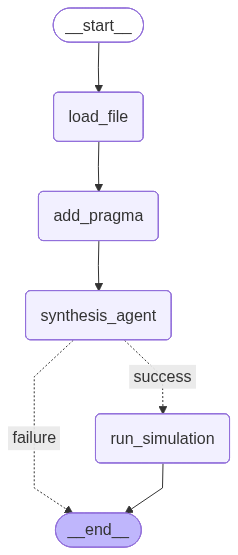

In [ ]:
from IPython.display import Image, display

try:
    display(Image(app.get_graph().draw_mermaid_png()))
except Exception:
    # This requires pygraphviz or similar; falls back to text if unavailable
    print("Graph compiled successfully. Visualization requires extra dependencies.")

In [ ]:
input_msg = {
    "file_path": "/content/MachSuite/aes/aes/aes.c",
    "pragma_type": "HLS",
    "retry_count": 0,
    "max_retries": 3,
    "working_dir": "/content/MachSuite/aes/aes",
    "tb_file": "aes_test.c",
    "top_fname": "aes256_encrypt_ecb"
}

In [ ]:
for chunk in app.stream(input_msg):
    print(chunk)

{'load_file': {'code': '/*\n*   Byte-oriented AES-256 implementation.\n*   All lookup tables replaced with \'on the fly\' calculations.\n*/\n#include "aes.h"\n\n#define F(x)   (((x)<<1) ^ ((((x)>>7) & 1) * 0x1b))\n#define FD(x)  (((x) >> 1) ^ (((x) & 1) ? 0x8d : 0))\n\n#define BACK_TO_TABLES\n#ifdef BACK_TO_TABLES\n\nconst uint8_t sbox[256] = {\n    0x63, 0x7c, 0x77, 0x7b, 0xf2, 0x6b, 0x6f, 0xc5,\n    0x30, 0x01, 0x67, 0x2b, 0xfe, 0xd7, 0xab, 0x76,\n    0xca, 0x82, 0xc9, 0x7d, 0xfa, 0x59, 0x47, 0xf0,\n    0xad, 0xd4, 0xa2, 0xaf, 0x9c, 0xa4, 0x72, 0xc0,\n    0xb7, 0xfd, 0x93, 0x26, 0x36, 0x3f, 0xf7, 0xcc,\n    0x34, 0xa5, 0xe5, 0xf1, 0x71, 0xd8, 0x31, 0x15,\n    0x04, 0xc7, 0x23, 0xc3, 0x18, 0x96, 0x05, 0x9a,\n    0x07, 0x12, 0x80, 0xe2, 0xeb, 0x27, 0xb2, 0x75,\n    0x09, 0x83, 0x2c, 0x1a, 0x1b, 0x6e, 0x5a, 0xa0,\n    0x52, 0x3b, 0xd6, 0xb3, 0x29, 0xe3, 0x2f, 0x84,\n    0x53, 0xd1, 0x00, 0xed, 0x20, 0xfc, 0xb1, 0x5b,\n    0x6a, 0xcb, 0xbe, 0x39, 0x4a, 0x4c, 0x58, 0xcf,\n    0xd0, 0xef, 

/tmp/ipykernel_16920/3120851842.py:45: LangGraphDeprecatedSinceV10: create_react_agent has been moved to `langchain.agents`. Please update your import to `from langchain.agents import create_agent`. Deprecated in LangGraph V1.0 to be removed in V2.0.
  agent = create_react_agent(llm, tools=[run_synthesis_tool], prompt=system_prompt)


--- Agent attempting synthesis on aes_optimised.c ---
/content/MachSuite/aes/aes
--- Agent attempting synthesis on aes_optimised.c ---
/content/MachSuite/aes/aes
{'synthesis_agent': {'error': None, 'modified_code': '/*\n*   Byte-oriented AES-256 implementation.\n*   All lookup tables replaced with \'on the fly\' calculations.\n*/\n#include "aes.h"\n\n#define F(x)   (((x)<<1) ^ ((((x)>>7) & 1) * 0x1b))\n#define FD(x)  (((x) >> 1) ^ (((x) & 1) ? 0x8d : 0))\n\n#define BACK_TO_TABLES\n#ifdef BACK_TO_TABLES\n\nconst uint8_t sbox[256] = {\n    0x63, 0x7c, 0x77, 0x7b, 0xf2, 0x6b, 0x6f, 0xc5,\n    0x30, 0x01, 0x67, 0x2b, 0xfe, 0xd7, 0xab, 0x76,\n    0xca, 0x82, 0xc9, 0x7d, 0xfa, 0x59, 0x47, 0xf0,\n    0xad, 0xd4, 0xa2, 0xaf, 0x9c, 0xa4, 0x72, 0xc0,\n    0xb7, 0xfd, 0x93, 0x26, 0x36, 0x3f, 0xf7, 0xcc,\n    0x34, 0xa5, 0xe5, 0xf1, 0x71, 0xd8, 0x31, 0x15,\n    0x04, 0xc7, 0x23, 0xc3, 0x18, 0x96, 0x05, 0x9a,\n    0x07, 0x12, 0x80, 0xe2, 0xeb, 0x27, 0xb2, 0x75,\n    0x09, 0x83, 0x2c, 0x1a, 0x1b, 0x

In [ ]:
result = run_bambu_synthesis(
    c_file_name="aes.c",
    top_fname="aes256_encrypt_ecb",
    generate_tb="aes_test.c",
    working_directory="/content/MachSuite/aes/aes"
)

/content/MachSuite/aes/aes


In [ ]:
run_bambu_simulation(
    tb_file="aes_test.c",
    top_fname="aes256_encrypt_ecb",
    working_dir="/content/MachSuite/aes/aes"
)

 ==  Bambu executed with: /tmp/.mount_bambuM08q0w/usr/bin/bambu --generate-interface=INFER --generate-tb=aes_test.c --top-fname=aes256_encrypt_ecb --simulate -v1 -I../../common aes.c 


********************************************************************************
                    ____                  _
                   | __ )  __ _ _ __ ___ | |_   _   _
                   |  _ \ / _` | '_ ` _ \| '_ \| | | |
                   | |_) | (_| | | | | | | |_) | |_| |
                   |____/ \__,_|_| |_| |_|_.__/ \__,_|

********************************************************************************
                         High-Level Synthesis Tool

                         Politecnico di Milano - DEIB
                          System Architectures Group
********************************************************************************
                Copyright (C) 2004-2024 Politecnico di Milano
 Version: PandA 2024.10 - Revision c2ba6936ca2ed63137095fea0b630a1c66e20e63-main

  An

" ==  Bambu executed with: /tmp/.mount_bambuM08q0w/usr/bin/bambu --generate-interface=INFER --generate-tb=aes_test.c --top-fname=aes256_encrypt_ecb --simulate -v1 -I../../common aes.c \n\n\n********************************************************************************\n                    ____                  _\n                   | __ )  __ _ _ __ ___ | |_   _   _\n                   |  _ \\ / _` | '_ ` _ \\| '_ \\| | | |\n                   | |_) | (_| | | | | | | |_) | |_| |\n                   |____/ \\__,_|_| |_| |_|_.__/ \\__,_|\n\n********************************************************************************\n                         High-Level Synthesis Tool\n\n                         Politecnico di Milano - DEIB\n                          System Architectures Group\n********************************************************************************\n                Copyright (C) 2004-2024 Politecnico di Milano\n Version: PandA 2024.10 - Revision c2ba6936ca2ed63137095fea0b63

## Optimized (aes_optimised.c) is generated by using the agentic approach.

### **Bambu HLS Optimization Comparison**

| Metric | Unoptimized (`aes.c`) | Optimized (`aes_optimised.c`) | Change / Impact |
| :--- | :--- | :--- | :--- |
| **Total Execution Cycles** | 1477 cycles | 331 cycles | **~77.6% Reduction** (Massive speedup) |
| **Estimated Max Frequency** | 112.04 MHz* | 255.34 MHz | **~128% Increase** (Better timing) |
| **Interface Protocol** | Array | AXI (`m_axi`) | Upgraded to standard bus protocol |
| **Internally Allocated Memory** | 1536 bytes | 256 bytes | **~83.3% Reduction** |
| **Synthesized Functions** | 2 (`aes_expandEncKey`, `aes256_encrypt_ecb`) | 1 (`aes256_encrypt_ecb` top module) | Indicates function inlining |
| **Total Flip-Flops** | 5,158 (1411 + 3747) | 12,310 | **~138% Increase** (Higher area footprint) |
| **Total Registers** | 284 (80 + 204) | 1,018 | **~258% Increase** |
| **Multiplexers (2-to-1 eq)**| 233 (72 + 161) | 566 | **~143% Increase** |
| **Estimated Resource Area** | 23,237 (1982 + 21255) | 48,888 | **~110% Increase** (Excluding MUX logic) |



---

### **Key Takeaways**

* **Performance vs. Area Trade-off:** This is a classic example of HLS optimization. By likely unrolling loops and inlining the key expansion function, your total latency dropped from 1477 to 331 cycles. Combined with the frequency jump to 255 MHz, the absolute execution time of the optimized hardware is exponentially faster.
* **Resource Utilization:** To achieve this speedup, the synthesizer had to instantiate significantly more parallel hardware. Your Flip-Flops and Registers more than doubled, and the core logic area increased by roughly 110%.
* **Memory Efficiency:** The optimized code relies heavily on registers rather than internally allocated memory blocks (BRAM/RAM), as seen by the drop in allocated memory from 1536 down to 256 bytes, paired with the massive spike in registers (284 to 1,018).
* **System Integration:** The optimized version upgraded the port interfaces from basic `array` protocols to memory-mapped AXI (`m_axi`), which makes the resulting IP much easier to integrate into standard SoC designs (like Xilinx Zynq or Altera SoCs).